In [2]:
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from pathlib import Path, PosixPath
import math
from scipy.interpolate import interp1d
from speclite import filters
import scipy.integrate as integrate

In [36]:
m1_diameter = 80 # cm
m2_diameter = 15.85 # cm
spider_width = 2 # cm this is a guess
num_spiders = 2
area_aperture = math.pi*(m1_diameter/2)**2 - math.pi*(m2_diameter/2)**2 - (m1_diameter-m2_diameter)*spider_width*num_spiders # cm^2

n_telescope_mirrors = 3
n_ao_mirrors = 7 # counted those in KalAO

src_mag = 5

target_spectrum_file = Path(f'LEO_spectrum_mag{src_mag}.fits') # can be .fits or .csv
telescope_coating_file = Path('protected_aluminium_reflectance.csv') #microns
ao_coating_file = Path('protected_aluminium_reflectance.csv')
qe_file = Path('qe_curve.csv') # angstr; asked ChatGPT to make arrays from an image of QE curve for Oxford Instr. OCAM2K camera 

wfs_band = (5000,7500)
#wfs_spectral_band = 'g'
#wfs_filter = filters.load_filter(f'sdss2010-{wfs_spectral_band}')

In [37]:
def transmitted_flux(wavelength, in_flux, transmission_file, n_surfaces):
    """ 
    wavelength [Angstrom]
    in_flux [erg / s / cm^2 / Angstrom] or power, [erg / s / Angstrom]
    transmission_file: csv file, SDSS filter, or tuple (min_lambda, max_lambda)
    n_surfaces which have this transmission coefficient
    """

    if type(transmission_file) == PosixPath:

        refl_data = np.loadtxt(transmission_file, delimiter=',', skiprows=1)
        wavelength_trans, frac_transmitted = refl_data[:, 0], refl_data[:, 1] # unit TBD, percent

        if wavelength_trans[0] > 10: # wavelength likely given in angstrom, nothing to change
            wavelength_a = wavelength_trans
        elif wavelength_trans[0] < 10: # wavelength likely given in microns, convert to angstrom
            wavelength_a = wavelength_trans*1e4

    elif type(transmission_file) == filters.FilterResponse:

        wfs_filter = transmission_file
        wavelength_a, frac_transmitted = wfs_filter.wavelength, wfs_filter.response*100 #angstr., percent
        expanded_transmittance = np.interp(
            wavelength,
            wavelength_a,
            frac_transmitted,
            left=0.0,
            right=0.0
        )
        wavelength_a = wavelength
        frac_transmitted = expanded_transmittance

    elif type(transmission_file) == tuple:
        
        lb_wlen, ub_wlen = transmission_file
        wavelength_a = wavelength[(wavelength > lb_wlen) & (wavelength < ub_wlen)]
        frac_transmitted = np.ones(len(wavelength_a))
        expanded_transmittance = np.interp(
            wavelength,
            wavelength_a,
            frac_transmitted,
            left=0.0,
            right=0.0
        )
        wavelength_a = wavelength
        frac_transmitted = expanded_transmittance*100

    wl_min = wavelength_a.min()
    wl_max = wavelength_a.max()

    mask = ((wavelength >= wl_min) &
            (wavelength <= wl_max))

    indices = np.where(mask)[0]

    wavelength_cropped = wavelength[mask]
    in_flux_cropped = in_flux[indices[0]:indices[-1]+1]

    interp_refl = interp1d(
        wavelength_a,
        frac_transmitted,
        kind='linear', 
        fill_value='extrapolate'
    )
    
    frac_transmitted_on_flux_grid = interp_refl(wavelength_cropped)
    transmitted_flux = in_flux_cropped*(frac_transmitted_on_flux_grid*0.01)**(n_surfaces)
    
    return wavelength_cropped, transmitted_flux

In [38]:
if target_spectrum_file.suffix == '.fits':
    hdu = fits.open(target_spectrum_file)
    target_wavelength, target_flux = hdu[1].data['WAVELENGTH'], hdu[1].data['FLUX'] #angstroms, FLAM (erg * s^-1 * cm^-2 * angstr^-1)
elif target_spectrum_file.suffix == '.csv': # this case is not really used
    target_data = np.loadtxt(target_spectrum_file, delimiter=',', skiprows=1)
    target_wavelength, target_flux = target_data[:, 0], target_data[:, 1] 

In [39]:
wavelength_crop1, transmitted_flux_telescope_per_sqcm = transmitted_flux(wavelength = target_wavelength, 
                                                                         in_flux = target_flux,
                                                                         transmission_file = telescope_coating_file, 
                                                                         n_surfaces = n_telescope_mirrors)

In [40]:
transmitted_flux_telescope = transmitted_flux_telescope_per_sqcm*area_aperture

In [41]:
wavelength_crop2, transmitted_flux_ao = transmitted_flux(wavelength = wavelength_crop1, 
                                                         in_flux = transmitted_flux_telescope,
                                                         transmission_file = ao_coating_file,
                                                         n_surfaces = n_ao_mirrors)

In [42]:
wavelength_crop3, transmitted_flux_wfs = transmitted_flux(wavelength = wavelength_crop2, 
                                                         in_flux = transmitted_flux_ao,
                                                         transmission_file = wfs_band, #wfs_filter,
                                                         n_surfaces = 1)

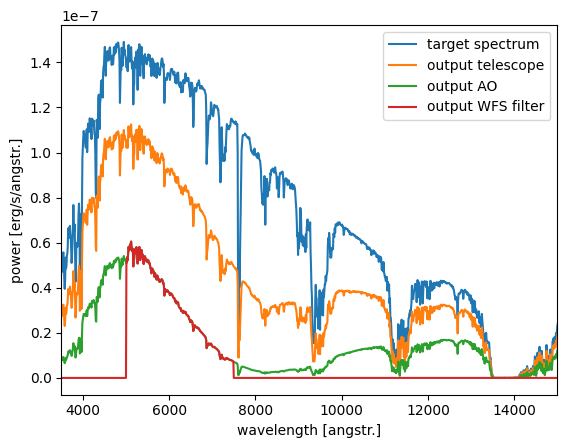

In [51]:
plt.plot(target_wavelength, target_flux*area_aperture, label='target spectrum')
plt.plot(wavelength_crop1, transmitted_flux_telescope, label='output telescope')
plt.plot(wavelength_crop2, transmitted_flux_ao, label='output AO')
plt.plot(wavelength_crop3, transmitted_flux_wfs, label='output WFS filter')
plt.legend()
plt.xlabel('wavelength [angstr.]')
plt.ylabel('power [erg/s/angstr.]')
plt.xlim(3500,15000)
plt.show()

In [52]:
h = 6.626e-27 # erg * s
c = 3e5 * 1e13 # Angstrom / s

In [53]:
n_subapertures = 76 # 76 illuminated out of 100 total, 108 / 144 respectively

E_ph = h*c / wavelength_crop3 # erg * s * Angstr * s^-1 / Angstr = erg

wfs_photon_flux = transmitted_flux_wfs / E_ph  # erg / s / Angstr / erg = number of photons/sec in wfs, for each wavelength bin

wfs_photon_flux_per_subap = wfs_photon_flux / n_subapertures

In [54]:
wavelength_crop4, transmitted_electrons_per_subap = transmitted_flux(wavelength = wavelength_crop3, 
                                                         in_flux = wfs_photon_flux_per_subap,
                                                         transmission_file = qe_file,
                                                         n_surfaces = 1)

Text(0.5, 1.0, 'WFS throughput per subaperture')

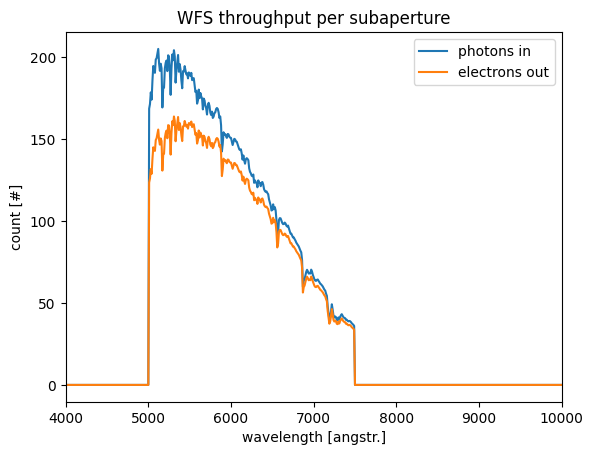

In [56]:
plt.plot(wavelength_crop3, wfs_photon_flux_per_subap, label='photons in')
plt.plot(wavelength_crop4, transmitted_electrons_per_subap, label='electrons out')
plt.xlim(wavelength_crop4[0], wavelength_crop4[-1])
plt.legend()
plt.xlabel('wavelength [angstr.]')
plt.ylabel('count [#]')
plt.title('WFS throughput per subaperture')

In [57]:
noise_at_2kHz = 0.4 # electron per px 
n_px_per_subap = 9

transmitted_electrons = transmitted_electrons_per_subap / n_px_per_subap
integrated_electron_flux_per_px = integrate.simpson(transmitted_electrons, wavelength_crop4) # electrons / px / s
print(integrated_electron_flux_per_px)

photon_noise = np.sqrt(integrated_electron_flux_per_px)
desired_SNR = 10
required_signal = np.sqrt(noise_at_2kHz**2 + photon_noise**2) * desired_SNR # electrons / px 
print(required_signal)

min_required_exp_time = required_signal/integrated_electron_flux_per_px 
max_operation_freq = 1/min_required_exp_time # Hz
print(f'max. feasible operation frequency: {round(max_operation_freq/1000, 3)} kHz')

30085.108159467687
1734.5105407424796
max. feasible operation frequency: 0.017 kHz


In [58]:
# Vega max AO operation frequencies: 0.001kHz(u), 2.9kHz(g) 2.3kHz(r), 0.46kHz(i), 0.03kHz(z)
